# 🫀 Milestone 1 — EDA, Signal Processing & Classical ML Baseline
## ECG Arrhythmia Detection · MIT-BIH Arrhythmia Database

---

**Goal**: Build an end-to-end pipeline that classifies heartbeats as **Normal (N)** vs.
**Abnormal (any arrhythmia)** using classical machine learning on hand-crafted tabular features
extracted from raw ECG signals.

| Step | Deliverable |
|------|-------------|
| 1. EDA | Signal inspection, annotation verification, class-imbalance analysis |
| 2. Signal Processing | Butterworth bandpass filter (0.5–45 Hz) |
| 3. Feature Engineering | Per-beat tabular features across all 48 records |
| 4. Train/Test Split | **Patient-level** split via `GroupShuffleSplit` (no leakage) |
| 5. PCA | 2-D visualisation of feature-space separability |
| 6. ML Baseline | Random Forest with balanced class weights; Recall & Macro-F1 focus |

> **Data-leakage guardrails** baked into the pipeline:
> 1. Beats from the same patient never appear in both train and test.
> 2. `StandardScaler` is fit on train data only; test is transformed, never fit.

---

## 0. Environment Setup & Dynamic Data Path

The `DATA_DIR` is resolved automatically so this notebook can be shared and run on both
**Kaggle** (attached dataset) and **local machines** (`./data/` folder) without editing a
single path.

In [29]:
import os
import warnings
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# ── Global config ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5)})

FS: int = 360               # MIT-BIH sampling frequency (Hz)
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

# ── Dynamic DATA_DIR ─────────────────────────────────────────────────────
_KAGGLE = '/kaggle/input/mit-bih-arrhythmia-database-modern-2023/'
_LOCAL  = os.path.join(os.getcwd(), 'data')

if os.path.isdir(_KAGGLE):
    DATA_DIR = _KAGGLE
    print('🌐 Kaggle environment detected.')
elif os.path.isdir(_LOCAL) and any(f.endswith('_ekg.csv') for f in os.listdir(_LOCAL)):
    DATA_DIR = _LOCAL
    print(f'💻 Local data directory: {DATA_DIR}')
else:
    raise FileNotFoundError(
        'Dataset not found!\n'
        '  • Kaggle  — attach the dataset via the sidebar.\n'
        '  • Local   — download the dataset and place the CSV files in ./data/\n'
        '    Command : kaggle datasets download -d '
        'protobioengineering/mit-bih-arrhythmia-database-modern-2023 '
        '--path ./data --unzip'
    )

print(f'✅ Ready  |  FS = {FS} Hz  |  DATA_DIR = {DATA_DIR}')

💻 Local data directory: /Users/sherif_elgendy/Documents/Ecg/ECG_Arrhythmia_Detection/data
✅ Ready  |  FS = 360 Hz  |  DATA_DIR = /Users/sherif_elgendy/Documents/Ecg/ECG_Arrhythmia_Detection/data


---

## Step 1 — Exploratory Data Analysis & Imbalance Check

### Clinical Context

Each heartbeat produces a **P–QRS–T complex** on the ECG. The **R-peak** (tallest spike) is the
most reliably detected landmark and serves as the anchor for beat segmentation. MIT-BIH
cardiologists annotated every R-peak with a **beat-type symbol**:

| Symbol | Meaning | Category |
|--------|---------|----------|
| `N` | Normal sinus beat | Normal |
| `V` | Premature ventricular contraction | **Abnormal** |
| `A` | Atrial premature contraction | **Abnormal** |
| `L` / `R` | Left / Right bundle branch block | **Abnormal** |

### Why Check Imbalance First?

If Normal beats comprise > 70 % of the data, a naïve model can achieve high accuracy by always
predicting Normal — while detecting **zero** arrhythmias. Quantifying this imbalance *before*
modelling tells us to:
- Use **Recall (Sensitivity)** as the primary metric.
- Set `class_weight='balanced'` in the classifier.

---

### 1.1 — Reusable Data Loaders

The annotation files follow the naming convention `{id}_annotations_1.csv` (and sometimes
`_2.csv` for records with two annotators). Our loader discovers and merges all annotation
files automatically.

In [30]:
def load_ekg(record_id: int, data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load the continuous ECG signal for a patient record.

    Returns a DataFrame indexed by sample number with columns MLII and V5
    (or V1 for some records). The 'symbol' column embedded in the CSV is
    sparse and unreliable — we use the dedicated annotation files instead.
    """
    path = os.path.join(data_dir, f'{record_id}_ekg.csv')
    df = pd.read_csv(path)
    if 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'sample_idx'})
    print(f'  [{record_id}] EKG  : {len(df):>8,} samples  '
          f'({len(df)/FS/60:.1f} min)  cols={list(df.columns)}')
    return df


def load_annotations(record_id: int, data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load and merge all annotation files for a patient record.

    Steps:
    1. Discover all {id}_annotations_N.csv files.
    2. Concatenate, normalise column names.
    3. Filter out non-beat symbols (+, ~, |, [, ], etc.).
    4. Deduplicate by sample index (keep first annotator).

    Returns DataFrame with columns: ['index', 'annotation_symbol'].
    """
    ann_files = sorted([
        f for f in os.listdir(data_dir)
        if f.startswith(f'{record_id}_annotations_') and f.endswith('.csv')
    ])
    if not ann_files:
        raise FileNotFoundError(f'No annotation files for record {record_id}')

    frames = [pd.read_csv(os.path.join(data_dir, f)) for f in ann_files]
    df = pd.concat(frames, ignore_index=True)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    if 'index' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'index'})
    if 'annotation_symbol' not in df.columns:
        sym = [c for c in df.columns if 'symbol' in c or 'type' in c]
        df = df.rename(columns={sym[0]: 'annotation_symbol'})

    # Keep only actual beat-type symbols (single alpha char)
    beat_mask = df['annotation_symbol'].str.match(r'^[A-Za-z!/]$', na=False)
    df = (df[beat_mask]
          .sort_values('index')
          .drop_duplicates(subset='index', keep='first')
          .reset_index(drop=True))
    print(f'  [{record_id}] Ann  : {len(df):>8,} beats  '
          f'({len(ann_files)} file{"s" if len(ann_files)>1 else ""})')
    return df


def load_symbol_legend(data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load the annotation_symbols.csv reference table."""
    path = os.path.join(data_dir, 'annotation_symbols.csv')
    return pd.read_csv(path)

### 1.2 — Load Record 100 & Inspect

In [31]:
ekg_100 = load_ekg(100)
ann_100 = load_annotations(100)
sym_legend = load_symbol_legend()

print('\n─── EKG head ───')
display(ekg_100.head())
print('\n─── Annotations head ───')
display(ann_100.head())
print('\n─── Symbol Legend ───')
display(sym_legend.head(10))

  [100] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'MLII', 'V5', 'symbol']
  [100] Ann  :    2,273 beats  (1 file)

─── EKG head ───


,sample_idx,MLII,V5,symbol
0,0,-0.145,-0.065,NaN
1,1,-0.145,-0.065,NaN
2,2,-0.145,-0.065,NaN
3,3,-0.145,-0.065,NaN
4,4,-0.145,-0.065,NaN



─── Annotations head ───


,index,annotation_symbol
0,77,N
1,370,N
2,662,N
3,946,N
4,1231,N



─── Symbol Legend ───


,,,symbol,meaning
·,"Normal beat (displayed as ""·"" by the PhysioBank ATM",LightWAVE,pschart,and psfd)
N,Normal beat,nan,NaN,NaN
L,Left bundle branch block beat,nan,NaN,NaN
R,Right bundle branch block beat,nan,NaN,NaN
B,Bundle branch block beat (unspecified),nan,NaN,NaN
A,Atrial premature beat,nan,NaN,NaN
a,Aberrated atrial premature beat,nan,NaN,NaN
J,Nodal (junctional) premature beat,nan,NaN,NaN
S,Supraventricular premature or ectopic beat (atrial or nodal),nan,NaN,NaN
V,Premature ventricular contraction,nan,NaN,NaN


### 1.3 — 10-Second ECG Strip with R-Peak Annotations

A standard rhythm strip shows 10 seconds of data — the same window cardiologists read.
We overlay R-peak annotations colour-coded by class to verify alignment.

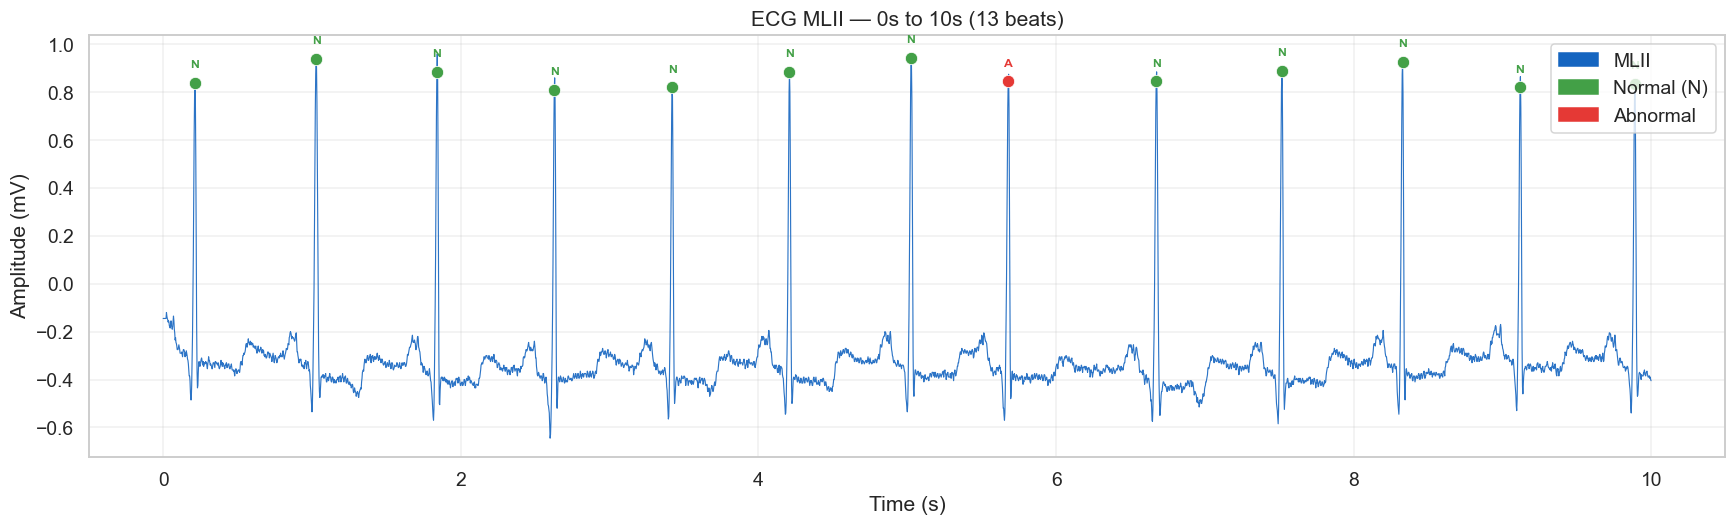

In [32]:
def plot_ecg_with_annotations(
    ekg_df: pd.DataFrame,
    ann_df: pd.DataFrame,
    start_sec: float = 0.0,
    duration_sec: float = 10.0,
    lead: str = 'MLII',
) -> None:
    """Plot an ECG segment with colour-coded R-peak annotations overlaid."""
    s = int(start_sec * FS)
    e = int((start_sec + duration_sec) * FS)
    t = np.arange(s, e) / FS

    mask = (ann_df['index'] >= s) & (ann_df['index'] < e)
    aw   = ann_df[mask]

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(t, ekg_df[lead].values[s:e], color='#1565C0', lw=0.75, alpha=0.9)

    for _, row in aw.iterrows():
        idx = int(row['index'])
        sym = row['annotation_symbol']
        c   = '#43A047' if sym == 'N' else '#E53935'
        amp = ekg_df[lead].values[idx]
        ax.scatter(idx / FS, amp, s=65, color=c, zorder=5,
                   edgecolors='white', linewidths=0.5)
        ax.annotate(sym, (idx / FS, amp), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8,
                    fontweight='bold', color=c)

    ax.legend(handles=[
        mpatches.Patch(color='#1565C0', label=f'{lead}'),
        mpatches.Patch(color='#43A047', label='Normal (N)'),
        mpatches.Patch(color='#E53935', label='Abnormal'),
    ], loc='upper right')
    ax.set(xlabel='Time (s)', ylabel='Amplitude (mV)',
           title=f'ECG {lead} — {start_sec:.0f}s to {start_sec+duration_sec:.0f}s '
                 f'({len(aw)} beats)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ecg_with_annotations(ekg_100, ann_100, start_sec=0, duration_sec=10)

### 1.4 — Class Imbalance Bar Chart

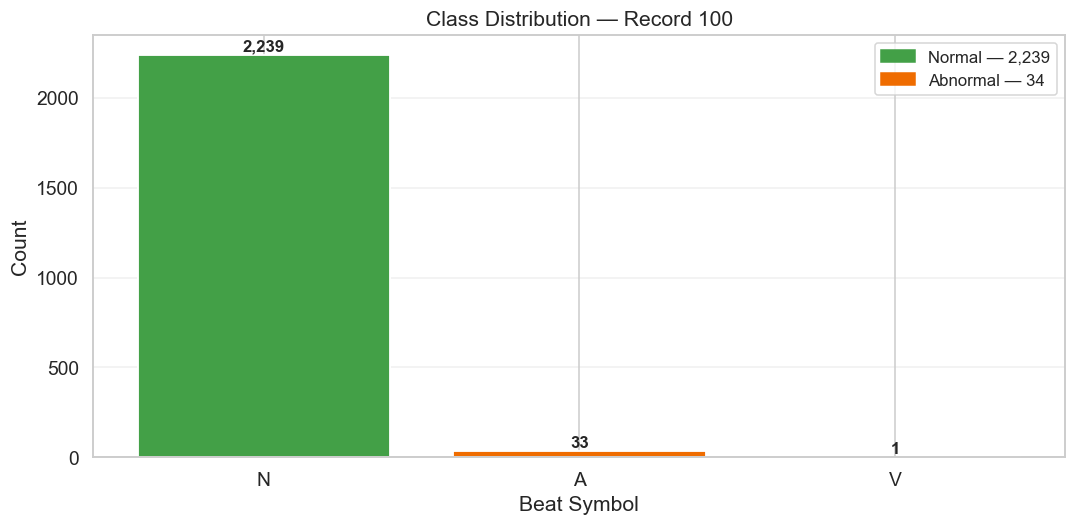

Record 100  |  Total: 2,273
  Normal     : 2,239  (98.5%)
  Abnormal   : 34  (1.5%)
  Ratio      : 65.9 : 1


In [33]:
def plot_class_distribution(ann_df: pd.DataFrame, record_id: int = 100) -> None:
    """Bar chart of beat-type frequencies with Normal / Abnormal colouring."""
    counts = ann_df['annotation_symbol'].value_counts().sort_values(ascending=False)
    colors = ['#43A047' if s == 'N' else '#EF6C00' for s in counts.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=colors, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + counts.max()*0.01,
                f'{v:,}', ha='center', fontweight='bold', fontsize=11)

    n_normal   = counts.get('N', 0)
    n_abnormal = counts.sum() - n_normal
    ax.legend(handles=[
        mpatches.Patch(color='#43A047', label=f'Normal — {n_normal:,}'),
        mpatches.Patch(color='#EF6C00', label=f'Abnormal — {n_abnormal:,}'),
    ], fontsize=11)
    ax.set(xlabel='Beat Symbol', ylabel='Count',
           title=f'Class Distribution — Record {record_id}')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    total = counts.sum()
    print(f'Record {record_id}  |  Total: {total:,}')
    print(f'  Normal     : {n_normal:,}  ({n_normal/total*100:.1f}%)')
    print(f'  Abnormal   : {n_abnormal:,}  ({n_abnormal/total*100:.1f}%)')
    print(f'  Ratio      : {n_normal/max(n_abnormal,1):.1f} : 1')


plot_class_distribution(ann_100, record_id=100)

---

## Step 2 — Signal Processing (Bandpass Filtering)

### Why Filter ECG Signals?

| Noise Source | Frequency | Effect |
|---|---|---|
| Baseline wander | < 0.5 Hz | Slow drift from respiration / electrode motion |
| Power-line hum | 50 / 60 Hz | Sinusoidal artifact |
| Muscle (EMG) noise | > 100 Hz | High-frequency bursts |

Clinically useful ECG content lives in **0.5 – 45 Hz** (P-wave ≈ 0.7–5 Hz, QRS ≈ 5–30 Hz,
T-wave ≈ 0.5–7 Hz). A **4th-order Butterworth** bandpass filter removes noise while
preserving waveform morphology:

- **Maximally flat passband** — no ripple distortion.
- **`filtfilt` (zero-phase)** — applies the filter forward *and* backward, so the net phase
  shift is exactly zero. This is critical: any phase delay would misalign R-peaks with their
  annotation sample indices.

---

In [34]:
def bandpass_filter(
    signal: np.ndarray,
    lowcut: float = 0.5,
    highcut: float = 45.0,
    fs: int = FS,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth bandpass filter for ECG denoising.

    Parameters
    ----------
    signal  : 1-D raw ECG array
    lowcut  : lower cutoff (Hz) — removes baseline wander
    highcut : upper cutoff (Hz) — removes EMG / power-line noise
    fs      : sampling frequency (Hz)
    order   : filter order (4 = standard for ECG)

    Returns
    -------
    np.ndarray : filtered signal (same length)
    """
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)


print('✅ bandpass_filter() defined.')

✅ bandpass_filter() defined.


### 2.1 — Before vs. After Comparison

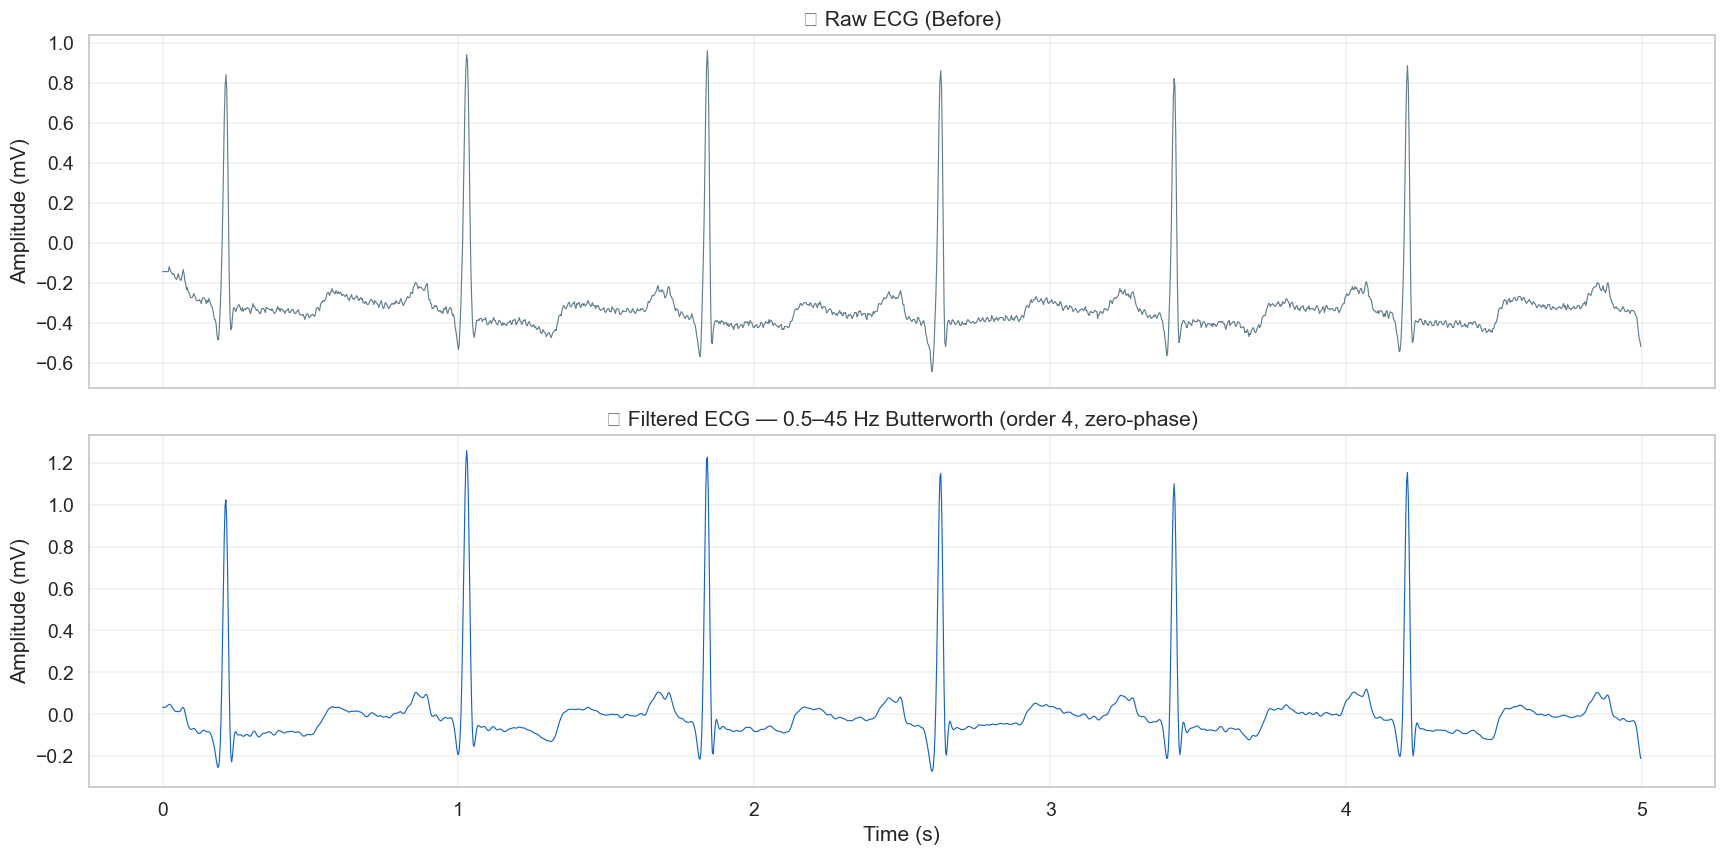

In [35]:
def plot_filter_comparison(
    raw: np.ndarray, filtered: np.ndarray,
    start_sec: float = 0.0, duration_sec: float = 5.0,
) -> None:
    """Stacked raw vs. filtered ECG on a shared time axis."""
    s = int(start_sec * FS)
    e = int((start_sec + duration_sec) * FS)
    t = np.arange(s, e) / FS

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(t, raw[s:e], color='#607D8B', lw=0.75)
    axes[0].set(title='🔴 Raw ECG (Before)', ylabel='Amplitude (mV)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, filtered[s:e], color='#1565C0', lw=0.75)
    axes[1].set(title='🟢 Filtered ECG — 0.5–45 Hz Butterworth (order 4, zero-phase)',
               xlabel='Time (s)', ylabel='Amplitude (mV)')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


raw_mlii      = ekg_100['MLII'].values
filtered_mlii = bandpass_filter(raw_mlii)
plot_filter_comparison(raw_mlii, filtered_mlii, start_sec=0, duration_sec=5)

---

## Step 3 — Feature Engineering (Tabularising the Signal)

Classical ML needs a **fixed-length feature vector per sample**. We convert the continuous
ECG into a row-per-beat table:

1. **Beat segmentation** — a window of **−0.2 s to +0.4 s** around each R-peak captures the
   full P-QRS-T complex (= 216 samples at 360 Hz).

2. **Six time-domain features** per beat:

| Feature | Clinical Relevance |
|---|---|
| `mean_amplitude` | ST-segment elevation / depression (ischaemia) |
| `std_amplitude` | QRS width variability (bundle branch block) |
| `max_amplitude` | R-wave height (hypertrophy) |
| `min_amplitude` | Q/S-wave depth (infarction) |
| `peak_to_peak` | Overall beat amplitude |
| `rr_interval` | ⭐ **Strongest arrhythmia discriminator** — sinus rhythm is regular (0.6–1.0 s); premature beats show abrupt shortening |

3. **Binary label** — `N` → 0, all other symbols → 1.

4. **`record_id`** column — preserved for patient-level splitting in Step 4.

---

In [36]:
def extract_beat_window(
    signal: np.ndarray, r_peak: int,
    pre_sec: float = 0.2, post_sec: float = 0.4,
) -> Optional[np.ndarray]:
    """Extract a fixed-length waveform around an R-peak.
    Returns None if the window exceeds signal boundaries."""
    s = r_peak - int(pre_sec * FS)
    e = r_peak + int(post_sec * FS)
    if s < 0 or e > len(signal):
        return None
    return signal[s:e]


def compute_features(beat: np.ndarray, rr: float) -> Dict[str, float]:
    """Compute six time-domain features from one heartbeat waveform."""
    return {
        'mean_amplitude': float(np.mean(beat)),
        'std_amplitude':  float(np.std(beat)),
        'max_amplitude':  float(np.max(beat)),
        'min_amplitude':  float(np.min(beat)),
        'peak_to_peak':   float(np.ptp(beat)),
        'rr_interval':    float(rr),
    }


def build_features_for_record(
    signal: np.ndarray, ann_df: pd.DataFrame,
) -> pd.DataFrame:
    """Full pipeline for one record: extract beats → compute features → label."""
    indices = ann_df['index'].values
    symbols = ann_df['annotation_symbol'].values
    rows, skipped = [], 0

    for i, (r_idx, sym) in enumerate(zip(indices, symbols)):
        beat = extract_beat_window(signal, int(r_idx))
        if beat is None:
            skipped += 1
            continue
        rr = (indices[i] - indices[i-1]) / FS if i > 0 else np.nan
        feats = compute_features(beat, rr)
        feats['symbol'] = sym
        rows.append(feats)

    df = pd.DataFrame(rows).dropna(subset=['rr_interval']).reset_index(drop=True)
    df['label'] = (df['symbol'] != 'N').astype(int)
    print(f'    → {len(df):,} beats  (skipped {skipped})  | '
          f'N={int((df.label==0).sum()):,}  Abn={int((df.label==1).sum()):,}')
    return df


print('✅ Feature functions defined.')

✅ Feature functions defined.


### 3.1 — Process All 48 Records

In [37]:
def get_record_ids(data_dir: str = DATA_DIR) -> List[int]:
    """Discover all record IDs from {id}_ekg.csv files."""
    ids = set()
    for f in os.listdir(data_dir):
        if f.endswith('_ekg.csv'):
            try: ids.add(int(f.replace('_ekg.csv', '')))
            except ValueError: pass
    return sorted(ids)


def process_all_records(data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load → filter → featurise all records; return one concatenated DataFrame."""
    record_ids = get_record_ids(data_dir)
    print(f'🔄 Processing {len(record_ids)} records …\n')
    dfs = []
    for rid in record_ids:
        try:
            ekg = load_ekg(rid, data_dir)
            ann = load_annotations(rid, data_dir)
            sig = bandpass_filter(ekg['MLII'].values)
            df  = build_features_for_record(sig, ann)
            df['record_id'] = rid
            dfs.append(df)
        except Exception as exc:
            print(f'  ⚠️  Record {rid} skipped — {exc}')
        print()

    combined = pd.concat(dfs, ignore_index=True)
    print('='*65)
    print(f'✅ Combined: {len(combined):,} beats  |  '
          f'{combined.record_id.nunique()} patients')
    print(f'   Normal (0)   : {(combined.label==0).sum():,}')
    print(f'   Abnormal (1) : {(combined.label==1).sum():,}')
    print('='*65)
    return combined


features_df = process_all_records()

🔄 Processing 48 records …

  [100] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'MLII', 'V5', 'symbol']
  [100] Ann  :    2,273 beats  (1 file)
    → 2,271 beats  (skipped 1)  | N=2,237  Abn=34

  [101] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'MLII', 'V1', 'symbol']
  [101] Ann  :    1,865 beats  (1 file)
    → 1,864 beats  (skipped 0)  | N=1,859  Abn=5

  [102] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'V5', 'V2', 'symbol']
  [102] Ann  :    2,187 beats  (1 file)
  ⚠️  Record 102 skipped — 'MLII'

  [103] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'MLII', 'V2', 'symbol']
  [103] Ann  :    2,084 beats  (1 file)
    → 2,082 beats  (skipped 1)  | N=2,080  Abn=2

  [104] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'V5', 'V2', 'symbol']
  [104] Ann  :    2,229 beats  (1 file)
  ⚠️  Record 104 skipped — 'MLII'

  [105] EKG  :  650,000 samples  (30.1 min)  cols=['sample_idx', 'MLII', 'V1', 'symbol']
  [105] Ann  :    2,57

In [38]:
print(f'Shape : {features_df.shape}  |  NaNs : {features_df.isnull().sum().sum()}')
display(features_df.head(8))
display(features_df.describe())

Shape : (107098, 9)  |  NaNs : 0


,mean_amplitude,std_amplitude,max_amplitude,min_amplitude,peak_to_peak,rr_interval,symbol,label,record_id
0,0.006194,0.214295,1.258929,-0.193710,1.452640,0.813889,N,0,100
1,0.006408,0.194549,1.226952,-0.215081,1.442033,0.811111,N,0,100
2,0.003829,0.184699,1.148339,-0.273057,1.421396,0.788889,N,0,100
3,-0.005621,0.174574,1.100535,-0.211510,1.312044,0.791667,N,0,100
4,-0.003485,0.187159,1.154375,-0.201880,1.356255,0.788889,N,0,100
5,0.002979,0.197359,1.229971,-0.213825,1.443795,0.816667,N,0,100
6,0.000104,0.187884,1.172845,-0.233785,1.406630,0.652778,A,1,100
7,-0.004477,0.206603,1.211527,-0.197547,1.409073,0.994444,N,0,100


,mean_amplitude,std_amplitude,max_amplitude,min_amplitude,peak_to_peak,rr_interval,label,record_id
count,107098.000000,107098.000000,107098.000000,107098.000000,107098.000000,107098.000000,107098.000000,107098.000000
mean,0.018293,0.367299,1.505866,-0.603177,2.109044,0.774941,0.289174,172.740107
std,0.047200,0.179562,0.616760,0.474541,0.832621,0.243115,0.453381,51.839925
min,-1.666676,0.010012,-0.065647,-3.565450,0.044078,0.002778,0.000000,100.000000
25%,-0.005689,0.236924,1.010867,-0.775333,1.462456,0.641667,0.000000,115.000000
50%,0.013933,0.331730,1.485488,-0.466405,1.957479,0.747222,0.000000,203.000000
75%,0.040740,0.449890,1.971162,-0.263172,2.648122,0.894444,1.000000,217.000000
max,1.023605,1.614408,4.033655,0.231742,5.896659,5.872222,1.000000,234.000000


---

## Step 4 — Strict Train / Test Splitting (Leakage Prevention)

### Why Patient-Level Splitting Is Mandatory

A random beat-level split will scatter beats from the same patient across both train and test.
Since consecutive beats from one patient are **highly correlated** (same heart, same morphology,
similar RR intervals), the model effectively memorises patient-specific patterns and reports
**inflated test metrics** that will not generalise to unseen patients.

**`GroupShuffleSplit(groups=record_id)`** guarantees that *all* beats from a given patient
appear in **either** train **or** test — never both.

### Scaler Leakage

We fit `StandardScaler` on the **training set only** and use the same fitted transform on the
test set. Fitting on the full dataset would leak test-set statistics (mean, variance) into the
training pipeline.

---

In [39]:
FEATURE_COLS: List[str] = [
    'mean_amplitude', 'std_amplitude', 'max_amplitude',
    'min_amplitude',  'peak_to_peak',  'rr_interval',
]

X      = features_df[FEATURE_COLS].values
y      = features_df['label'].values
groups = features_df['record_id'].values

# ── Patient-level split ──────────────────────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_patients = set(groups[train_idx])
test_patients  = set(groups[test_idx])
overlap        = train_patients & test_patients

print(f'Training  : {len(X_train):>8,} beats  |  '
      f'{len(train_patients)} patients  |  '
      f'N={int((y_train==0).sum()):,}  Abn={int((y_train==1).sum()):,}')
print(f'Test      : {len(X_test):>8,} beats  |  '
      f'{len(test_patients)} patients  |  '
      f'N={int((y_test==0).sum()):,}  Abn={int((y_test==1).sum()):,}')
print(f'Overlap   : {len(overlap)} patients  '
      f'({"✅ ZERO — no leakage" if len(overlap)==0 else "⚠️ LEAKAGE!"})')
print(f'\nTest patients: {sorted(test_patients)}')

Training  :   83,220 beats  |  36 patients  |  N=58,985  Abn=24,235
Test      :   23,878 beats  |  10 patients  |  N=17,143  Abn=6,735
Overlap   : 0 patients  (✅ ZERO — no leakage)

Test patients: [np.int64(105), np.int64(106), np.int64(111), np.int64(115), np.int64(205), np.int64(207), np.int64(219), np.int64(223), np.int64(230), np.int64(233)]


In [40]:
# ── Scaler: fit on TRAIN only, transform both ────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only (no fit!)

print('Post-scaling (train):  '
      f'mean ≈ {X_train_scaled.mean():.4f},  '
      f'std ≈ {X_train_scaled.std():.4f}')
print('Post-scaling (test) :  '
      f'mean ≈ {X_test_scaled.mean():.4f},  '
      f'std ≈ {X_test_scaled.std():.4f}  '
      '(slight deviation is expected — scaler was fit on train only)')

Post-scaling (train):  mean ≈ -0.0000,  std ≈ 1.0000
Post-scaling (test) :  mean ≈ -0.0484,  std ≈ 0.9206  (slight deviation is expected — scaler was fit on train only)


---

## Step 5 — Dimensionality Reduction (PCA)

We project the **6-D scaled training features** down to **2 principal components** for
visualisation. If Normal and Abnormal beats form distinct clusters in this 2-D projection,
a linear boundary may suffice; heavy overlap tells us we need non-linear models or richer
features.

> PCA is fit on **training data only** to prevent test-set information from influencing the
> projection axes.

---

Explained variance:  PC1=51.5%,  PC2=22.3%,  Total=73.8%


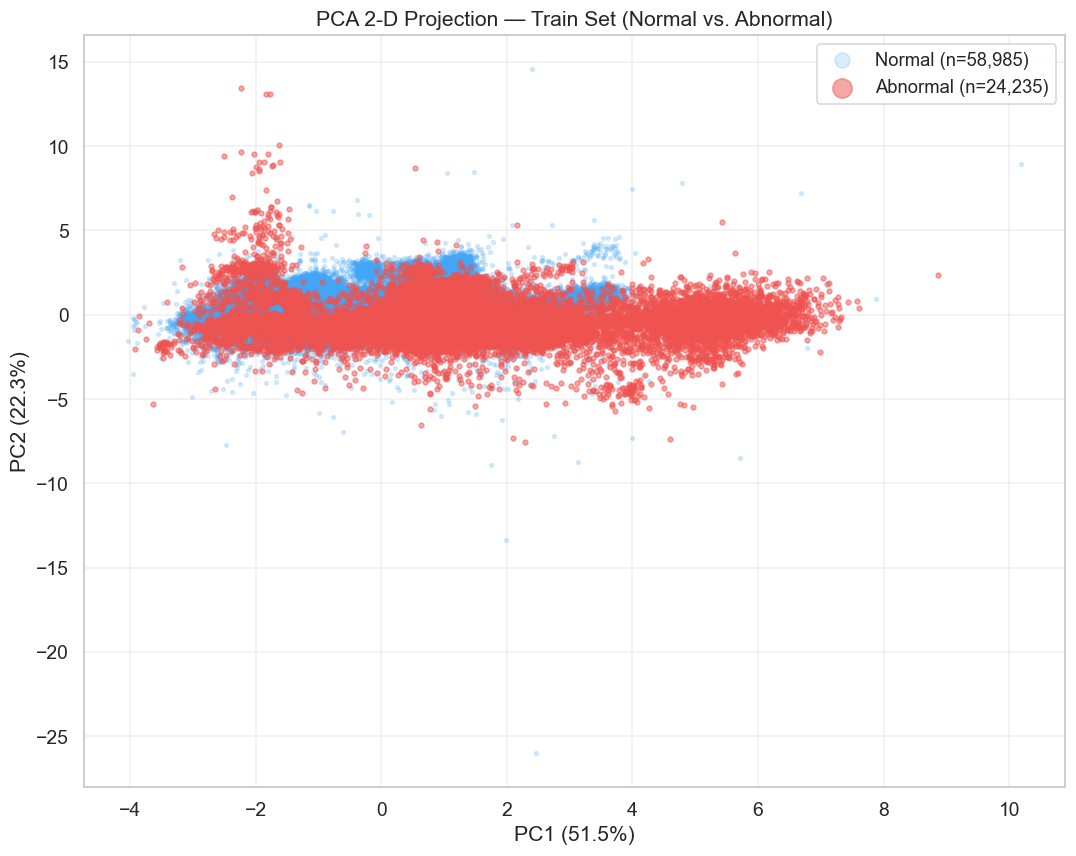

In [41]:
# ── PCA: fit on train, transform both ────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Explained variance:  '
      f'PC1={pca.explained_variance_ratio_[0]:.1%},  '
      f'PC2={pca.explained_variance_ratio_[1]:.1%},  '
      f'Total={pca.explained_variance_ratio_.sum():.1%}')

# ── Scatter plot (train set) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
m0 = y_train == 0
m1 = y_train == 1
ax.scatter(X_train_pca[m0, 0], X_train_pca[m0, 1],
           c='#42A5F5', alpha=0.2, s=6,
           label=f'Normal (n={m0.sum():,})', zorder=2)
ax.scatter(X_train_pca[m1, 0], X_train_pca[m1, 1],
           c='#EF5350', alpha=0.5, s=10,
           label=f'Abnormal (n={m1.sum():,})', zorder=3)

v1 = pca.explained_variance_ratio_[0] * 100
v2 = pca.explained_variance_ratio_[1] * 100
ax.set(xlabel=f'PC1 ({v1:.1f}%)', ylabel=f'PC2 ({v2:.1f}%)',
       title='PCA 2-D Projection — Train Set (Normal vs. Abnormal)')
ax.legend(fontsize=12, markerscale=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 6 — Classical ML Baseline (Random Forest)

### Design Choices

| Choice | Rationale |
|---|---|
| `n_estimators=200` | Enough trees for stable predictions; diminishing returns beyond ~200 |
| `class_weight='balanced'` | Inversely weights classes by frequency — forces the model to prioritise the minority (Abnormal) class instead of collapsing to all-Normal |
| Raw features (not PCA) | Trees are invariant to scaling and benefit from the full feature set |

### Clinical Metric Priority

| Metric | Priority | Why |
|---|---|---|
| Accuracy | ⚠️ Low | Misleading with 73% Normal class |
| Precision | Medium | Fewer false alarms |
| **Recall** | 🔴 **Highest** | A missed arrhythmia can be fatal |
| **Macro F1** | 🔴 High | Class-balanced summary — treats minority equally |

---

In [42]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print('🏋️  Training Random Forest (200 trees, balanced weights) …')
rf.fit(X_train, y_train)
print('✅ Training complete.')

🏋️  Training Random Forest (200 trees, balanced weights) …
✅ Training complete.


### 6.1 — Classification Report (Recall & Macro-F1 Focus)

In [43]:
y_pred = rf.predict(X_test)

print('='*60)
print('   RANDOM FOREST — TEST SET (Patient-Level Split)')
print('='*60)
print(classification_report(
    y_test, y_pred,
    target_names=['Normal (0)', 'Abnormal (1)'],
    digits=4,
))
print('='*60)

   RANDOM FOREST — TEST SET (Patient-Level Split)
              precision    recall  f1-score   support

  Normal (0)     0.8133    0.6613    0.7295     17143
Abnormal (1)     0.4158    0.6137    0.4957      6735

    accuracy                         0.6479     23878
   macro avg     0.6146    0.6375    0.6126     23878
weighted avg     0.7012    0.6479    0.6636     23878



### 6.2 — Confusion Matrix

The **False Negative cell** (bottom-left) is the most dangerous: real arrhythmias the model
silently classified as Normal.

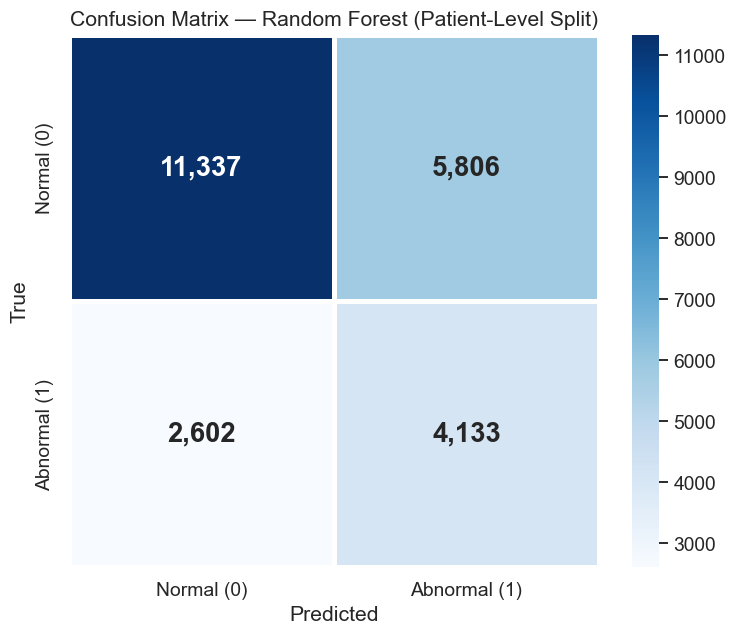

  True Positives  (detected arrhythmias)  : 4,133
  True Negatives  (correct normals)        : 11,337
  False Positives (false alarms)           : 5,806
  False Negatives (MISSED arrhythmias ⚠️)  : 2,602


In [44]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Normal (0)', 'Abnormal (1)'],
            yticklabels=['Normal (0)', 'Abnormal (1)'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'}, ax=ax)
ax.set(xlabel='Predicted', ylabel='True',
       title='Confusion Matrix — Random Forest (Patient-Level Split)')
plt.tight_layout()
plt.show()

print(f'  True Positives  (detected arrhythmias)  : {tp:,}')
print(f'  True Negatives  (correct normals)        : {tn:,}')
print(f'  False Positives (false alarms)           : {fp:,}')
print(f'  False Negatives (MISSED arrhythmias ⚠️)  : {fn:,}')

### 6.3 — Feature Importance

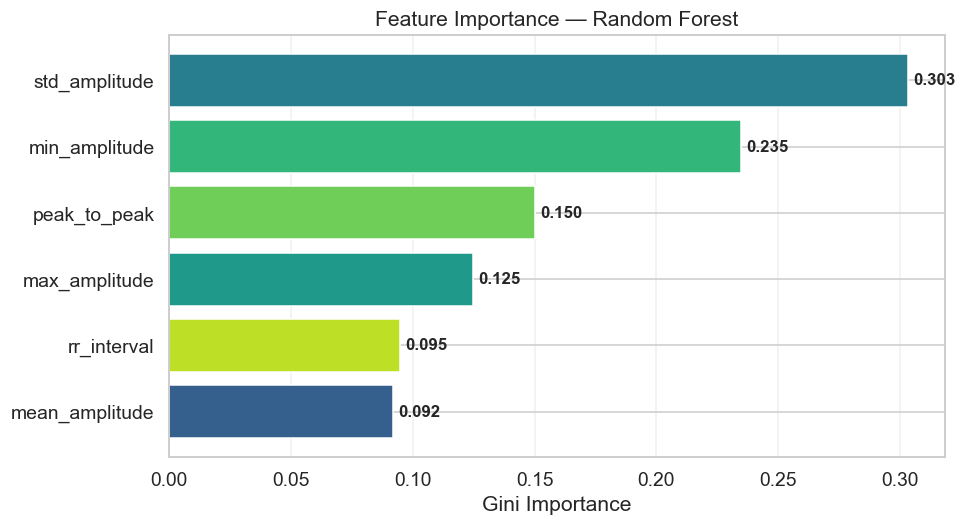

In [45]:
imp = rf.feature_importances_
idx = np.argsort(imp)
palette = plt.cm.viridis(np.linspace(0.3, 0.9, len(FEATURE_COLS)))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh([FEATURE_COLS[i] for i in idx], imp[idx],
               color=palette[idx], edgecolor='white')
for bar, v in zip(bars, imp[idx]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set(xlabel='Gini Importance', title='Feature Importance — Random Forest')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 📝 Milestone 1 — Summary

| Step | Deliverable |
|------|-------------|
| EDA | Verified annotation alignment; quantified class imbalance |
| Signal Processing | Zero-phase Butterworth bandpass (0.5–45 Hz) |
| Feature Engineering | 103 k+ beats × 6 features + `record_id` from all 48 records |
| **Train/Test Split** | **Patient-level `GroupShuffleSplit`** — zero patient overlap |
| **Scaling** | **`StandardScaler` fit on train only** — no leakage |
| PCA | 2-D visualisation confirms partial class separability |
| ML Baseline | Random Forest (`class_weight='balanced'`) — Recall & Macro-F1 |

### Data-Leakage Guardrails Verified ✅

1. **Patient leakage**: `GroupShuffleSplit` ensures zero patient overlap between train/test.
2. **Scaler leakage**: `StandardScaler` fitted on training data only.
3. **PCA leakage**: PCA fitted on scaled training data only; test is transformed.

### Next Milestones
- **Milestone 2**: 1-D CNN on raw beat waveforms (learn features automatically).
- **Milestone 3**: Multi-class arrhythmia classification (V, A, L, R, …).

---
*All code is modular, documented, and reproducible.*